Step 1 : Load required libraries

Step 2 : Load the data

Step 3 : Data Exploration

Step 4 : Data visualisaton

Step 5 : divide the data into train and testing

Step 6 : Applying machine learning algorithms


In [ ]:
### step 1 : Load required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


### Step 2 : Load the data

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to five Boston employment centres

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per ($10,000)

PTRATIO: pupil-teacher ratio by town

B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town

LSTAT: % lower status of the population

MEDV: Median value of owner-occupied homes in $1000s (target variable)

In [ ]:
mydata = pd.read_csv("/content/Boston_HousingDataSet.xls")
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
## Step 3 : Data Exploration
mydata.shape

(506, 14)

In [ ]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
### for checking null values
mydata.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
mydata.describe()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
mydata.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


### Step 4 : Data visualisation

<Axes: xlabel='MEDV', ylabel='Count'>

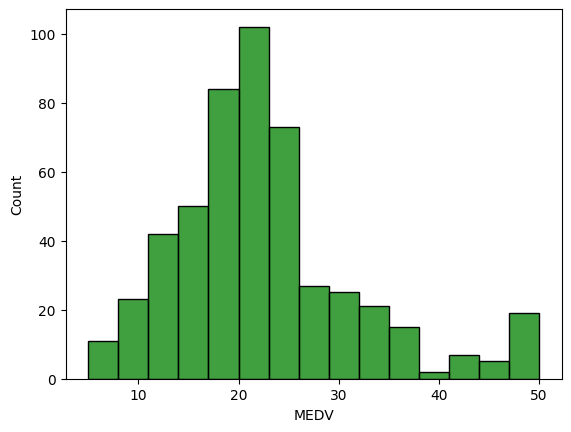

In [ ]:
### Histogram of target variable
import seaborn as sns

sns.histplot(mydata['MEDV'], bins = 15, color ="green")

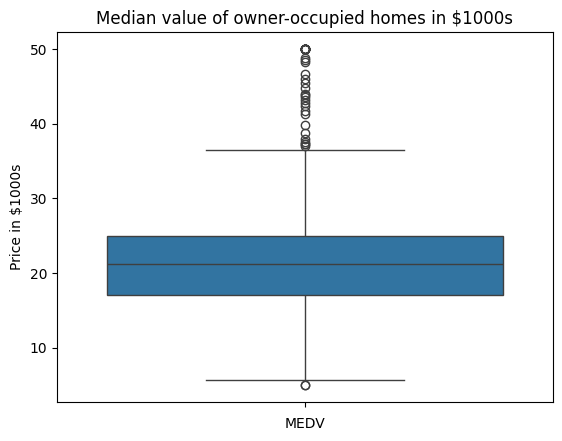

In [ ]:
sns.boxplot(mydata['MEDV'])
plt.title("Median value of owner-occupied homes in $1000s")
plt.xlabel("MEDV")
plt.ylabel("Price in $1000s")
plt.show()

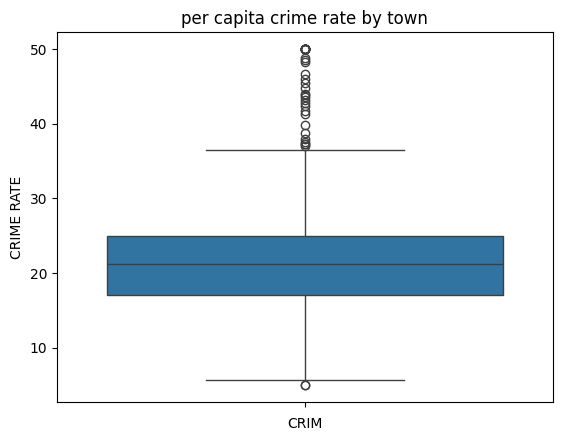

In [ ]:
### boxplot for crime rate
sns.boxplot(mydata['MEDV'])
plt.title("per capita crime rate by town")
plt.xlabel("CRIM")
plt.ylabel("CRIME RATE")
plt.show()


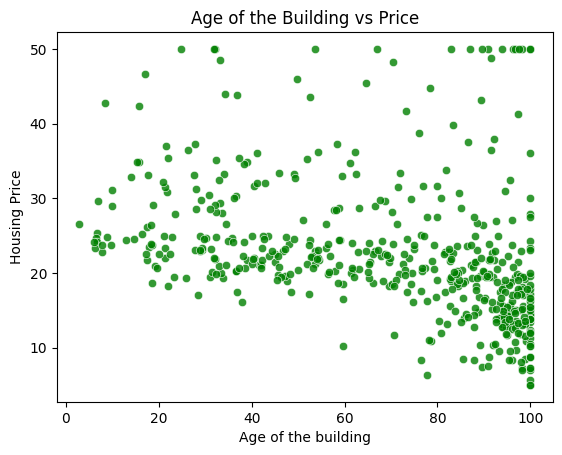

In [ ]:
### SCATTER PLOT
sns.scatterplot(x = "AGE", y = "MEDV", data = mydata, color = "Green", alpha =  0.8)
plt.title("Age of the Building vs Price")
plt.xlabel("Age of the building")
plt.ylabel("Housing Price")
plt.show()

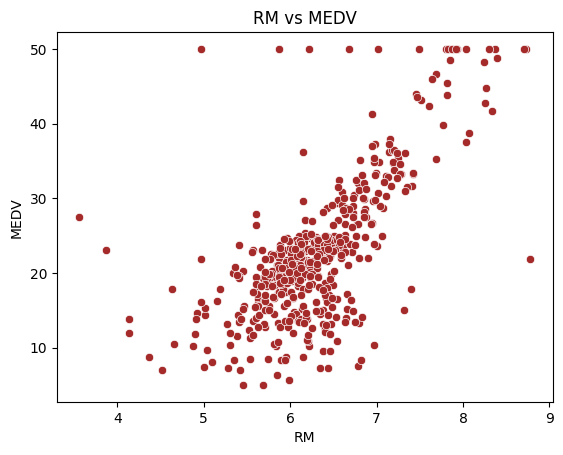

In [ ]:
### Scatter plot between RM vs MEDV
sns.scatterplot(x= 'RM', y= 'MEDV', data=mydata, color='brown')
plt.title('RM vs MEDV')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

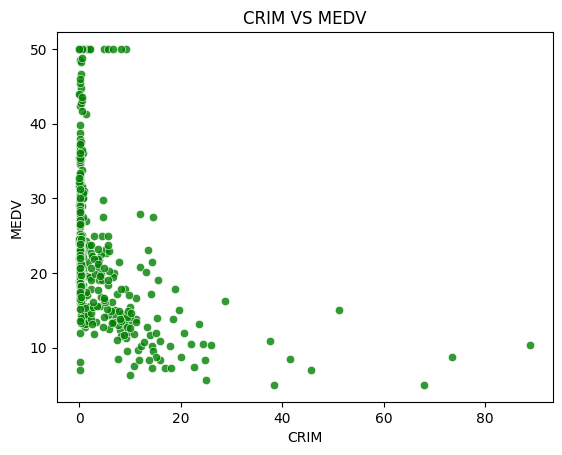

In [ ]:
## Scatter plot between CRIM VS MEDV
sns.scatterplot(x = "CRIM", y = "MEDV", data = mydata, color = "Green", alpha =  0.8)
plt.title("CRIM VS MEDV")
plt.xlabel("CRIM")
plt.ylabel("MEDV")
plt.show()

In [ ]:
### Barplots Average housing prices by accessibility of Road Highways
rad_medv_mean = mydata.groupby("RAD")["MEDV"].mean().reset_index()
rad_medv_mean

,RAD,MEDV
0,1,24.365000
1,2,26.833333
2,3,27.928947
3,4,21.387273
4,5,25.706957
5,6,20.976923
6,7,27.105882
7,8,30.358333
8,24,16.403788


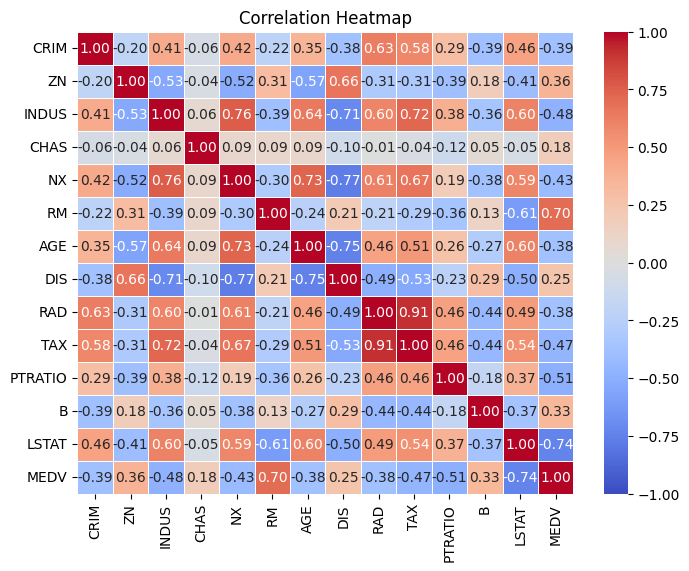

In [ ]:
corr = mydata.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='RAD', ylabel='MEDV'>

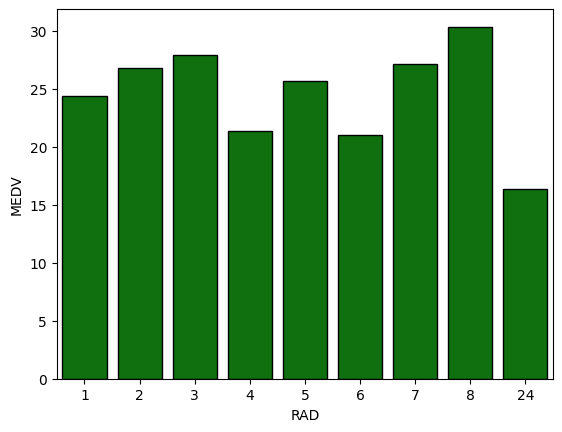

In [ ]:
sns.barplot(x = "RAD" , y = "MEDV" , data = rad_medv_mean, color = "Green", edgecolor = "Black")

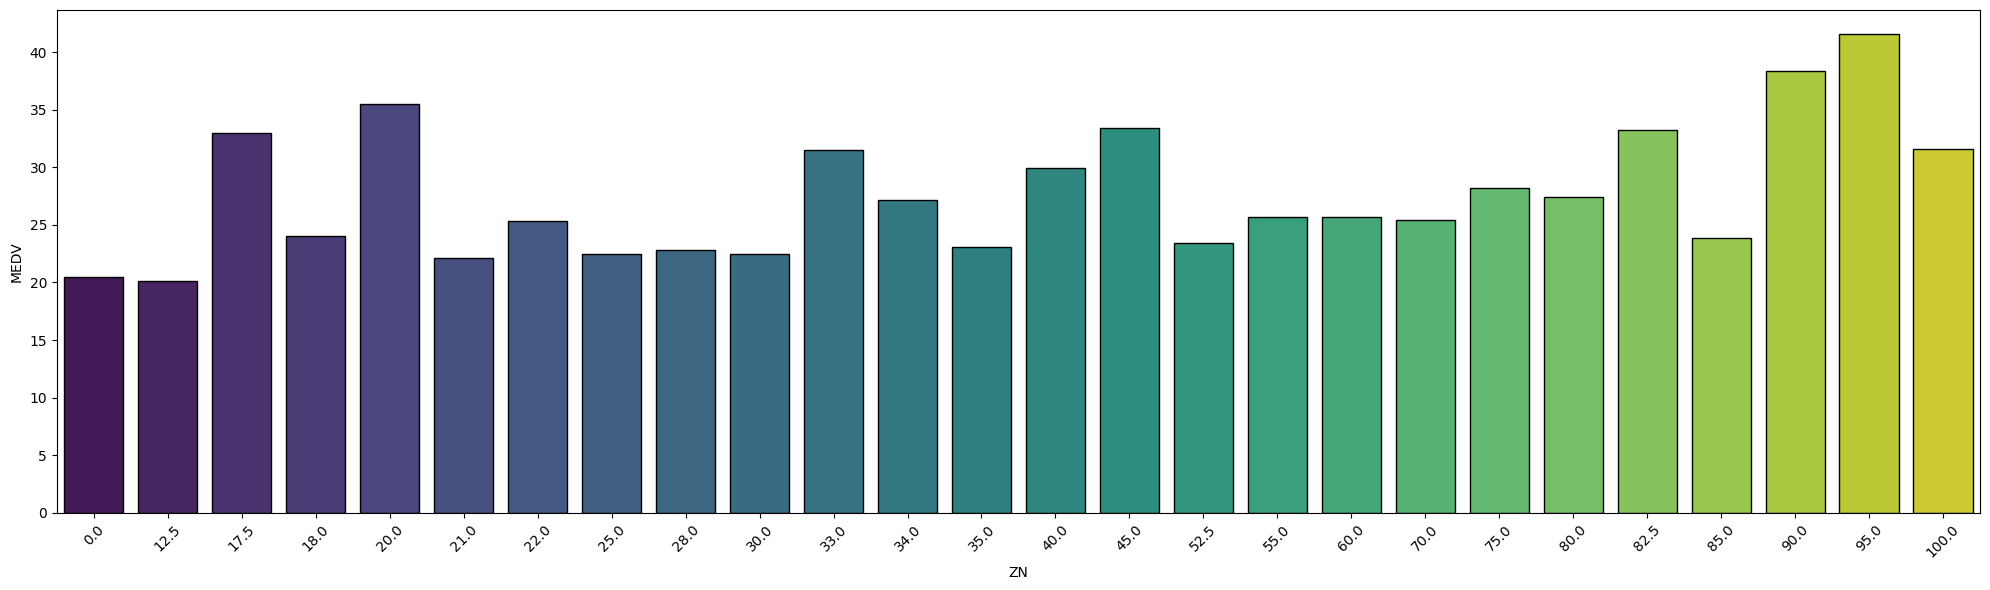

In [ ]:
ZN_medv_mean = mydata.groupby("ZN")["MEDV"].mean().reset_index()
figure_size =(20,6)
plt.figure(figsize =figure_size)
sns.barplot(x = "ZN" , y = "MEDV" , data = ZN_medv_mean, color = "Green", edgecolor = "Black", palette = "viridis")
plt.xticks(rotation = 45)
plt.tight_layout()

In [ ]:
X = mydata.drop(columns = ["MEDV"])
y = mydata["MEDV"]

In [ ]:
X.shape
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [ ]:
y.shape

(506,)

In [ ]:
X = mydata.drop("MEDV", axis = 1)
y = mydata["MEDV"]

In [ ]:
### Step5 : divide the data intro train and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.33, random_state =42)

In [ ]:
X_train.shape

(339, 13)

In [ ]:
y_train.shape

(339,)

In [ ]:
## Step 6: Applying machine Learning algorithms
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr_model = lr.fit(X_train, y_train)

In [ ]:
lr_model.coef_

array([-1.28749718e-01,  3.78232228e-02,  5.82109233e-02,  3.23866812e+00,
       -1.61698120e+01,  3.90205116e+00, -1.28507825e-02, -1.42222430e+00,
        2.34853915e-01, -8.21331947e-03, -9.28722459e-01,  1.17695921e-02,
       -5.47566338e-01])

In [ ]:
lr_model.intercept_

np.float64(33.33497575563631)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
rmse_lr = rmse(y_test, y_pred_lr)
rmse_lr

4.552364598463068

In [ ]:
from sklearn.metrics import r2_score as r2

r2_lr = r2(y_test, y_pred_lr)
r2_lr

0.7261570836552469

In [ ]:
### Decision tree regressor

from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)
rmse_dtr = rmse(y_test, y_pred_dtr)
r2_dtr = r2(y_test, y_pred_dtr)

In [ ]:
r2_dtr

0.7402311094857897

In [ ]:
### random forest method
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
y_pred_rf = rfr.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MSE: 10.619262365269464
RMSE: 3.258720970759765
MAPE: 0.1175996124826134
R2 Score: 0.8596792855244546
